In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append("../../src/")

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation

import scipy.stats as stats
from tqdm import tqdm
from network import FeedForward
from helper_functions import circular_gaussian

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [8]:
seed = 100 # 140

inh_1_scale = 0.3
inh_2_scale = 0.7
inh_3_scale = 1.1

network_inh_1 = FeedForward(inh="on", inh_type='co-tuned', inh_scale = inh_1_scale, seed=seed)
POs_1 = network_inh_1.get_POs_over_trials(network_inh_1.w_ef_baseline, network_inh_1.n_steps, 'stripe_rearing')
drift_mag_inh_1, drift_rate_inh_1, convergence_inh_1 = network_inh_1.get_metrics(network_inh_1.N, network_inh_1.n_days, network_inh_1.theta_stim, network_inh_1.POs)

network_inh_2 = FeedForward(inh="on", inh_type='co-tuned', inh_scale = inh_2_scale, seed=seed)
POs_2 = network_inh_2.get_POs_over_trials(network_inh_1.w_ef_baseline, network_inh_2.n_steps, 'stripe_rearing')
drift_mag_inh_2, drift_rate_inh_2, convergence_inh_2 = network_inh_2.get_metrics(network_inh_2.N, network_inh_2.n_days, network_inh_2.theta_stim, network_inh_2.POs)

network_inh_3 = FeedForward(inh="on", inh_type='co-tuned', inh_scale = inh_3_scale, seed=seed)
POs_3 = network_inh_3.get_POs_over_trials(network_inh_1.w_ef_baseline, network_inh_3.n_steps, 'stripe_rearing')
drift_mag_inh_3, drift_rate_inh_3, convergence_inh_3 = network_inh_3.get_metrics(network_inh_3.N, network_inh_3.n_days, network_inh_3.theta_stim, network_inh_3.POs)


setting seed: 100


100%|██████████| 840/840 [00:11<00:00, 74.58it/s]


setting seed: 100


100%|██████████| 840/840 [00:09<00:00, 84.90it/s]


setting seed: 100


100%|██████████| 840/840 [00:10<00:00, 82.18it/s]


/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_11019/3407646438.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


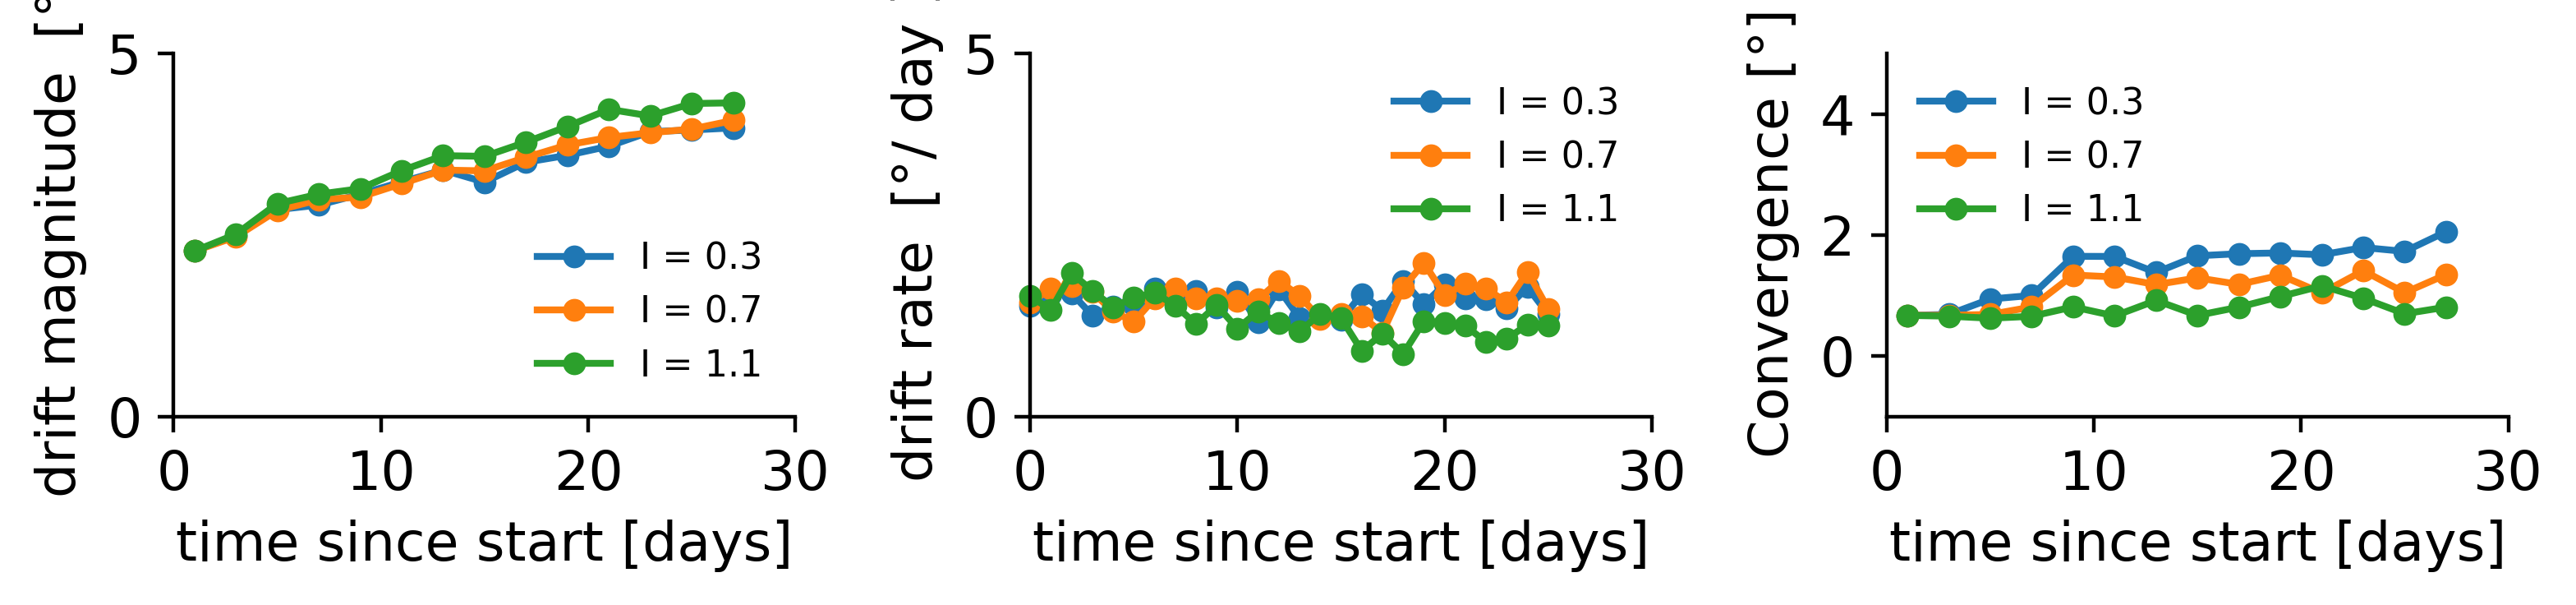

In [9]:
eo = 2

fig, axs = plt.subplots(1, 3, figsize=(8, 2), dpi=400)
axs[0].plot(np.arange(1, network_inh_1.n_days)[::eo], np.median(drift_mag_inh_1, axis=1)[:-1][::eo], ls='-', marker='o', ms=4, label=f'I = {inh_1_scale}', clip_on=False)
axs[0].plot(np.arange(1, network_inh_2.n_days)[::eo], np.median(drift_mag_inh_2, axis=1)[:-1][::eo], ls='-', marker='o', ms=4, label=f'I = {inh_2_scale}', clip_on=False)
axs[0].plot(np.arange(1, network_inh_3.n_days)[::eo], np.median(drift_mag_inh_3, axis=1)[:-1][::eo], ls='-', marker='o', ms=4, label=f'I = {inh_3_scale}', clip_on=False)

axs[0].set_ylim([0, 5]); axs[0].set_yticks([0, 5])
axs[0].set_xlabel('time since start [days]')
axs[0].set_ylabel(r'drift magnitude $ \; [\degree]$')
axs[0].set_xlim(0, 30)
axs[0].legend(frameon=False, fontsize=8)


axs[1].plot(np.mean(drift_rate_inh_1, axis=1)[:-1], ls='-', marker='o', ms=4, label=f'I = {inh_1_scale}', clip_on=False)
axs[1].plot(np.mean(drift_rate_inh_2, axis=1)[:-1], ls='-', marker='o', ms=4, label=f'I = {inh_2_scale}', clip_on=False)
axs[1].plot(np.mean(drift_rate_inh_3, axis=1)[:-1], ls='-', marker='o', ms=4, label=f'I = {inh_3_scale}', clip_on=False)

axs[1].set_ylim([0, 5]); axs[1].set_yticks([0, 5])
axs[1].set_xlabel('time since start [days]')
axs[1].set_ylabel(r'drift rate $ \; [\degree / $ day $]$')
axs[1].set_xlim(0, 30)  
axs[1].legend(frameon=False, fontsize=8)


axs[2].plot(np.arange(1, network_inh_1.n_days)[::eo], np.median(convergence_inh_1, axis=1)[::eo], ls='-', marker='o', ms=4, label=f'I = {inh_1_scale}', clip_on=False)
axs[2].plot(np.arange(1, network_inh_2.n_days)[::eo], np.median(convergence_inh_2, axis=1)[::eo], ls='-', marker='o', ms=4, label=f'I = {inh_2_scale}', clip_on=False)
axs[2].plot(np.arange(1, network_inh_3.n_days)[::eo], np.median(convergence_inh_3, axis=1)[::eo], ls='-', marker='o', ms=4, label=f'I = {inh_3_scale}', clip_on=False)

axs[2].set_ylim([-1, 5])
axs[2].set_xlim(0, 30)
axs[2].set_ylabel(r"Convergence $[\degree]$")
axs[2].set_xlabel('time since start [days]')

axs[2].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.show()

# fig.savefig("../../results/goggle_experiment/goggle_drift_3_levels_co-tuned_inh.svg")

In [6]:
num_stimuli = 500
N = 500
theta_list = np.linspace(0, 180, 500)

tuning_curves_initial = np.empty((N, num_stimuli))
tuning_curves_final = np.empty((N, num_stimuli))

for stim_num, theta in enumerate(theta_list):
    u = circular_gaussian(N, theta)
    i = network_inh_1.w_if.T.dot(u)
    e_initial = network_inh_1.w_ef_init.T.dot(u) - network_inh_1.w_ei.T.dot(i)
    e_initial[e_initial < 0] = 0
    tuning_curves_initial[:, stim_num] = e_initial
    
for stim_num, theta in enumerate(theta_list):
    u = circular_gaussian(N, theta)
    i = network_inh_1.w_if.T.dot(u)
    e_final = network_inh_1.W[:, :, -1].T.dot(u) - network_inh_1.w_ei.T.dot(i)
    e_final[e_final < 0] = 0
    tuning_curves_final[:, stim_num] = e_final

/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_11019/217019578.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


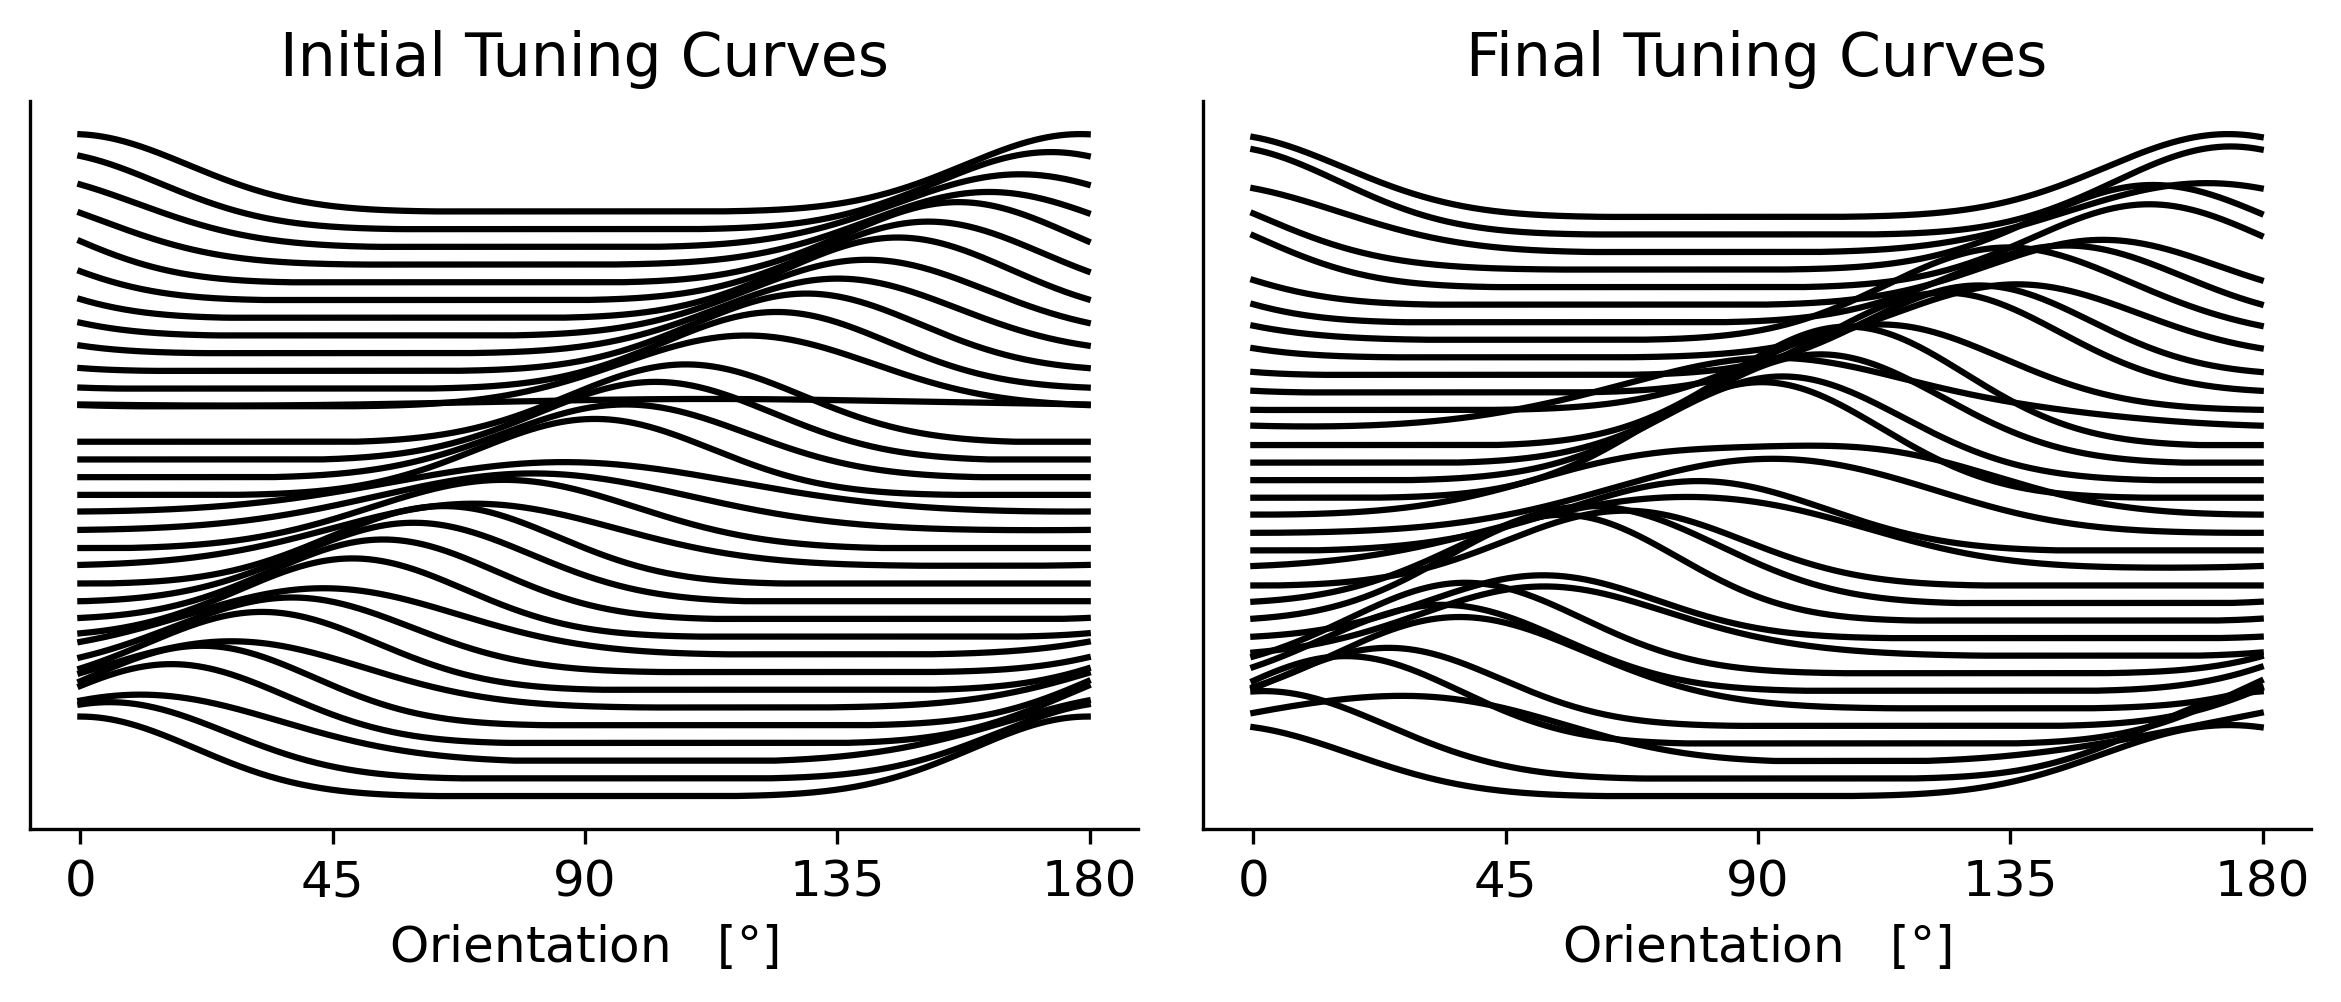

In [7]:

plt.rcParams['font.size'] = 12
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), dpi=300)

for i in range(0, N, 15):
    axs[0].plot(tuning_curves_initial[i] + 0.028*i, color='black')

    axs[0].set_xticks(np.arange(0, N+1, 125), np.linspace(0, 2*np.pi, 5))
    axs[0].set_xticklabels([0, 45, 90, 135, 180])
    axs[0].set_xlabel(r'Orientation  $ \; [\degree]$')

for i in range(0, N, 15):
    axs[1].plot(tuning_curves_final[i] + 0.028*i, color='black')

    axs[1].set_xticks(np.arange(0, N+1, 125), np.linspace(0, 2*np.pi, 5))
    axs[1].set_xticklabels([0, 45, 90, 135, 180])
    axs[1].set_xlabel(r'Orientation  $ \; [\degree]$')

axs[0].set_yticks([], [])
axs[1].set_yticks([], [])

axs[0].title.set_text("Initial Tuning Curves")
axs[1].title.set_text("Final Tuning Curves")

fig.tight_layout()
fig.savefig("../../results/goggle_experiment/tuning_curves_initial_vs_final.svg")
fig.show()